In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Numerical Analysis

In [22]:
df = pd.read_csv('token_usage_log.csv')
print("Data Info:")
display(df.info())
print("\nData Description:")
display(df.describe())
print("\nFirst Few Rows:")
display(df.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               140 non-null    object 
 1   Step                    140 non-null    object 
 2   Input Tokens (Prompt)   140 non-null    int64  
 3   Output Tokens (Answer)  140 non-null    int64  
 4   Total Tokens            140 non-null    int64  
 5   Latency (s)             75 non-null     float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.7+ KB


None


Data Description:


,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
count,140.000000,140.000000,140.000000,75.000000
mean,9626.800000,211.542857,10992.107143,5.118133
std,11468.598144,268.229081,13466.346555,4.883361
min,304.000000,3.000000,366.000000,0.910000
25%,732.750000,40.750000,864.000000,1.955000
50%,989.500000,114.000000,1678.500000,4.180000
75%,22882.000000,289.500000,23527.750000,5.875000
max,27433.000000,1526.000000,46895.000000,26.620000



First Few Rows:


,Timestamp,Step,Input Tokens (Prompt),Output Tokens (Answer),Total Tokens,Latency (s)
0,2026-04-19 16:44:36,Router_RB,668,14,682,NaN
1,2026-04-19 16:44:39,Generator_RB,486,205,691,NaN
2,2026-04-19 16:46:11,Router_RB,661,25,686,NaN
3,2026-04-19 16:46:14,Generator_RB,1240,100,1340,NaN
4,2026-04-19 17:03:17,Generator_RB,455,268,723,NaN


In [23]:
df = df.rename(columns={
    'Input Tokens (Prompt)': 'Input Tokens',
    'Output Tokens (Answer)': 'Output Tokens',
    'Latency (s)': 'Latency'
})

df['Extra Tokens'] = df['Total Tokens'] - df['Input Tokens'] - df['Output Tokens']
df['Model'] = df['Step'].apply(lambda x: 'Naive' if 'Generator (NAIVE RAG - Full DB)' in x else 'Router Based')

df.head()

,Timestamp,Step,Input Tokens,Output Tokens,Total Tokens,Latency,Extra Tokens,Model
0,2026-04-19 16:44:36,Router_RB,668,14,682,NaN,0,Router Based
1,2026-04-19 16:44:39,Generator_RB,486,205,691,NaN,0,Router Based
2,2026-04-19 16:46:11,Router_RB,661,25,686,NaN,0,Router Based
3,2026-04-19 16:46:14,Generator_RB,1240,100,1340,NaN,0,Router Based
4,2026-04-19 17:03:17,Generator_RB,455,268,723,NaN,0,Router Based


## Plots

### Cmap

In [24]:
df['Step'].unique()

array(['Router_RB', 'Generator_RB', 'Generator_Naive', 'Evaluator_RB',
       'Evaluator_Naive'], dtype=object)

In [ ]:
# Colormap for each Step category
router_based = "#3cb6aed6"
full_db = "#f93e3e"

step_cmap = {
    'Router_RB': router_based,
    'Generator_RB': router_based,
    'Generator_Naive': full_db,
    'Evaluator_RB': router_based,
    'Evaluator_Naive': full_db
}

model_cmap = {
    'Router Based': router_based,
    'Naive': full_db
}

### Comparison

#### Model Type Freq

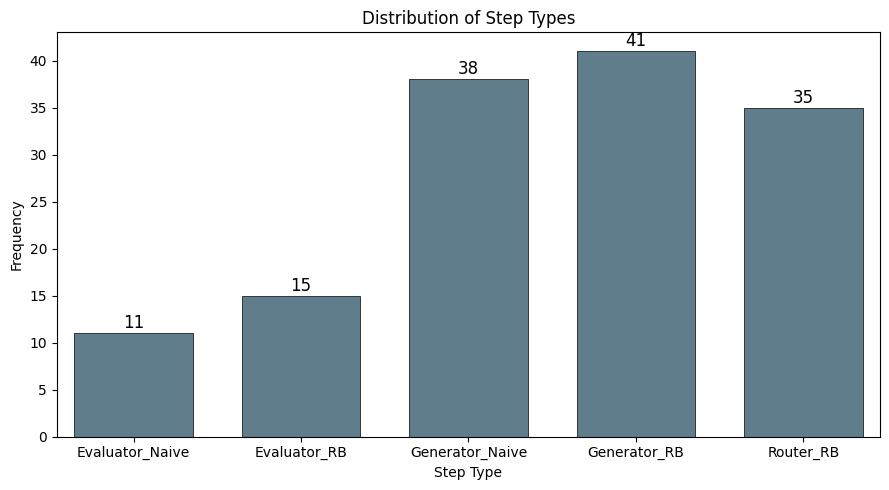

In [26]:
step_counts = df['Step'].value_counts().sort_index()
bar_colors = [step_cmap.get(step, '#607d8b') for step in step_counts.index]

plt.figure(figsize=(9, 5))
x = np.arange(len(step_counts)) * 0.48
bars = plt.bar(x, 
               step_counts.values, 
               width=0.34, 
               color=bar_colors,
               edgecolor='black',
               linewidth=0.5)

# Show value labels on top of each bar
for bar, v in zip(bars, step_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.1,
        str(v),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.xticks(x, step_counts.index)
plt.xlim(x.min() - 0.22, x.max() + 0.22)
plt.ylim(0, step_counts.max() + 2)
plt.title('Distribution of Step Types')
plt.xlabel('Step Type')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Average token per model

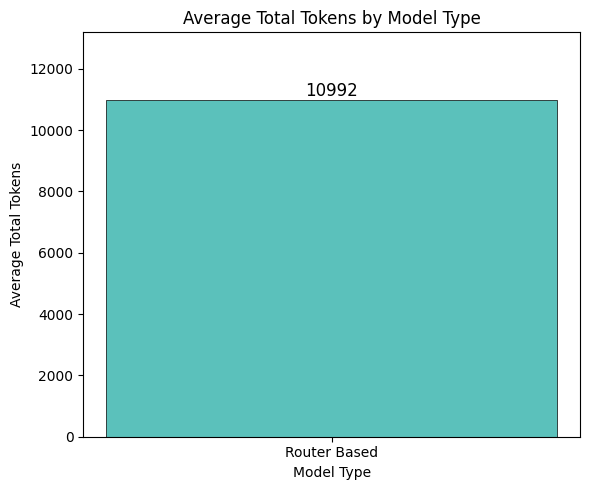

In [27]:
total_token_df = df.groupby('Model')['Total Tokens'].mean().reset_index()

bar_colors = [model_cmap.get(model, '#607d8b') for model in total_token_df['Model']]

plt.figure(figsize=(6, 5))
bars = plt.bar(total_token_df['Model'], 
               total_token_df['Total Tokens'], 
               color=bar_colors,
               edgecolor='black',
               linewidth=0.5)

# Show value labels on top of each bar
for bar, v in zip(bars, total_token_df['Total Tokens']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.1,
        f"{v:.0f}",
        ha='center',
        va='bottom',
        fontsize=12
    )
plt.title('Average Total Tokens by Model Type')
plt.xlabel('Model Type')
plt.ylabel('Average Total Tokens')
plt.ylim(0, total_token_df['Total Tokens'].max() * 1.2)
plt.tight_layout()

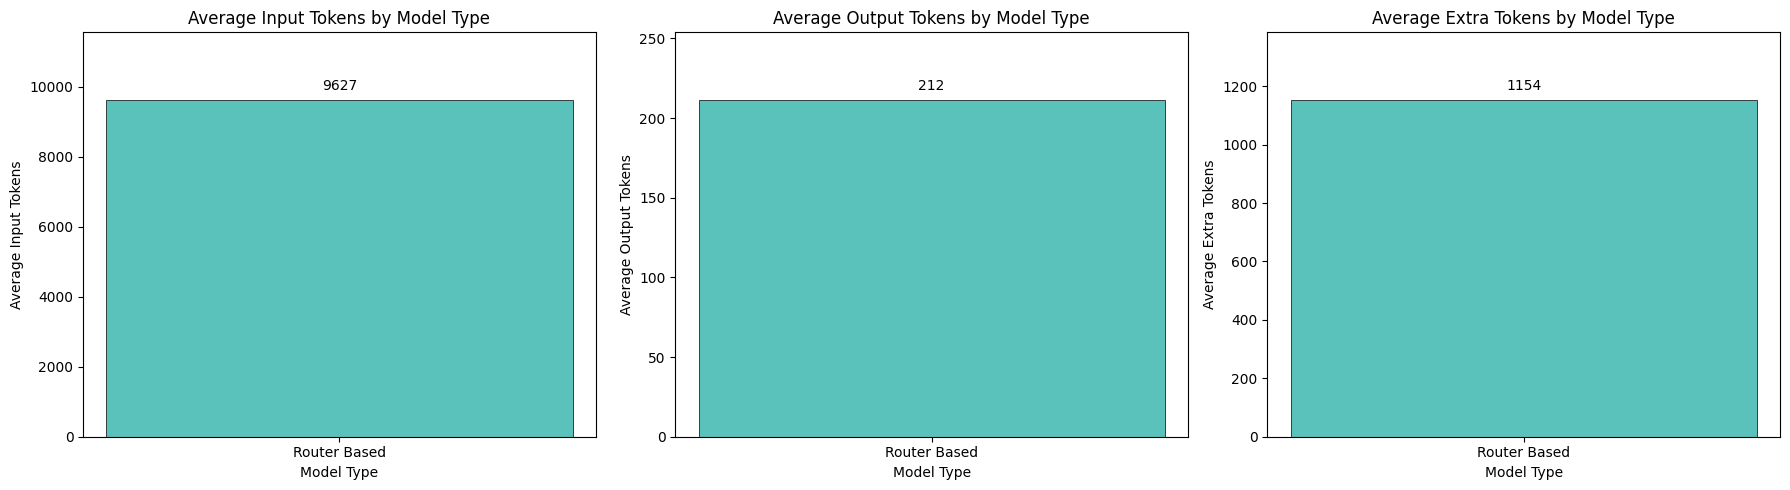

In [28]:
metrics = ['Input Tokens', 'Output Tokens', 'Extra Tokens']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, metrics):
    metric_df = df.groupby('Model')[metric].mean().reset_index()
    bar_colors = [model_cmap.get(model, '#607d8b') for model in metric_df['Model']]

    bars = ax.bar(
        metric_df['Model'],
        metric_df[metric],
        color=bar_colors,
        edgecolor='black',
        linewidth=0.5
    )

    for bar, v in zip(bars, metric_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + (metric_df[metric].max() * 0.02),
            f"{v:.0f}",
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_title(f'Average {metric} by Model Type')
    ax.set_xlabel('Model Type')
    ax.set_ylabel(f'Average {metric}')
    ax.set_ylim(0, metric_df[metric].max() * 1.2)

plt.tight_layout()
plt.show()